# Mouth Dataset Preprocessing

## Purpose

This notebook preprocesses the original dataset by detecting and cropping the mouth region from every image using MediaPipe Face Landmarker.

Instead of detecting facial landmarks during every training epoch, the mouth is extracted only once and saved as a new dataset.

This significantly reduces training time because the CNN trains directly on the cropped mouth images.

---

## Workflow

Original Dataset

↓

MediaPipe Face Detection

↓

Mouth Landmark Extraction

↓

Crop Mouth Region

↓

Resize to 128 × 128

↓

Save to New Dataset

↓

CNN Training

In [ ]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import os
from pathlib import Path
import cv2
import numpy as np
from tqdm import tqdm

import mediapipe as mp

from mediapipe.tasks import python
from mediapipe.tasks.python import vision

import matplotlib.pyplot as plt

from PIL import Image

import shutil
import time

In [ ]:
# ============================================================
# CONFIGURATION
# ============================================================

# -------- Dataset Paths --------

PROJECT_ROOT = Path.cwd()

# Original dataset (contains full-face images)
DATASET_ROOT = PROJECT_ROOT / "frames" / "dataset"

# New dataset (cropped mouth images will be saved here)
OUTPUT_DATASET = PROJECT_ROOT / "frames" / "mouth_dataset"

# MediaPipe Face Landmarker model
MODEL_PATH = PROJECT_ROOT / "assets" / "face_landmarker.task"

# -------- Image Settings --------

IMAGE_SIZE = 128

# -------- Supported Image Formats --------

VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

# -------- Class Labels --------

CLASSES = {

    "mouth_closed": 0,

    "talking": 1,

    "yawning": 2

}

# -------- Statistics --------

processed_images = 0

failed_images = 0

skipped_images = 0

print("=" * 60)
print("Configuration Loaded Successfully")
print("=" * 60)

print(f"Original Dataset : {DATASET_ROOT}")
print(f"Output Dataset   : {OUTPUT_DATASET}")
print(f"Image Size       : {IMAGE_SIZE} x {IMAGE_SIZE}")
print(f"Classes          : {list(CLASSES.keys())}")
print("=" * 60)

Configuration Loaded Successfully
Original Dataset : C:\Users\Omswaroop\OneDrive\Desktop\New folder\frames\dataset
Output Dataset   : C:\Users\Omswaroop\OneDrive\Desktop\New folder\frames\mouth_dataset
Image Size       : 128 x 128
Classes          : ['mouth_closed', 'talking', 'yawning']


In [11]:
# ============================================================
# CREATE OUTPUT DIRECTORY STRUCTURE
# ============================================================

os.makedirs(OUTPUT_DATASET, exist_ok=True)

for class_name in CLASSES:

    os.makedirs(

        os.path.join(
            OUTPUT_DATASET,
            class_name
        ),

        exist_ok=True

    )

print("Output folders created successfully.\n")

for class_name in CLASSES:

    print(

        os.path.join(
            OUTPUT_DATASET,
            class_name
        )

    )

Output folders created successfully.

C:\Users\Omswaroop\OneDrive\Desktop\New folder\frames\mouth_dataset\mouth_closed
C:\Users\Omswaroop\OneDrive\Desktop\New folder\frames\mouth_dataset\talking
C:\Users\Omswaroop\OneDrive\Desktop\New folder\frames\mouth_dataset\yawning


In [12]:
# ============================================================
# INITIALIZE MEDIAPIPE FACE LANDMARKER
# ============================================================

BaseOptions = python.BaseOptions

FaceLandmarker = vision.FaceLandmarker

FaceLandmarkerOptions = vision.FaceLandmarkerOptions

RunningMode = vision.RunningMode

options = FaceLandmarkerOptions(

    base_options=BaseOptions(

        model_asset_path=str(MODEL_PATH)

    ),

    running_mode=RunningMode.IMAGE,

    num_faces=1

)

detector = FaceLandmarker.create_from_options(

    options

)

print("MediaPipe Face Landmarker Loaded Successfully")

MediaPipe Face Landmarker Loaded Successfully


In [13]:
# ============================================================
# MOUTH LANDMARK INDICES
# ============================================================

MOUTH_POINTS = [

    61, 146, 91, 181, 84,

    17, 314, 405, 321, 375,

    291, 409, 270, 269, 267,

    0, 37, 39, 40, 185

]

print(f"Loaded {len(MOUTH_POINTS)} mouth landmark points.")

Loaded 20 mouth landmark points.


In [14]:
# ============================================================
# MOUTH CROPPING FUNCTION
# ============================================================

def crop_mouth(frame):

    try:

        rgb = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )

        mp_image = mp.Image(
            image_format=mp.ImageFormat.SRGB,
            data=rgb
        )

        result = detector.detect(mp_image)

        if len(result.face_landmarks) == 0:
            return None

        landmarks = result.face_landmarks[0]

        h, w = frame.shape[:2]

        points = []

        for idx in MOUTH_POINTS:

            x = int(landmarks[idx].x * w)
            y = int(landmarks[idx].y * h)

            points.append([x, y])

        points = np.array(points)

        x, y, bw, bh = cv2.boundingRect(points)

        pad_x = int(bw * 0.30)
        pad_y = int(bh * 0.40)

        x1 = max(0, x - pad_x)
        y1 = max(0, y - pad_y)

        x2 = min(w, x + bw + pad_x)
        y2 = min(h, y + bh + pad_y)

        mouth = frame[y1:y2, x1:x2]

        if mouth.size == 0:
            return None

        mouth = cv2.resize(
            mouth,
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        return mouth

    except Exception:

        return None

In [15]:
# ============================================================
# SCAN DATASET
# ============================================================

image_list = []

for class_name in CLASSES:

    folder = os.path.join(
        DATASET_ROOT,
        class_name
    )

    if not os.path.exists(folder):

        print(f"Folder not found : {folder}")

        continue

    for file in os.listdir(folder):

        if file.lower().endswith(VALID_EXTENSIONS):

            image_list.append(

                (

                    os.path.join(folder, file),

                    class_name,

                    file

                )

            )

print("=" * 60)

print(f"Total Images Found : {len(image_list):,}")

print("=" * 60)

Total Images Found : 268,249


In [16]:
# ============================================================
# PREPROCESS DATASET
# ============================================================

failed_files = []

start_time = time.time()

for image_path, class_name, filename in tqdm(

    image_list,

    desc="Processing Images"

):

    output_path = os.path.join(

        OUTPUT_DATASET,

        class_name,

        filename

    )

    # Skip already processed image

    if os.path.exists(output_path):

        skipped_images += 1

        continue

    frame = cv2.imread(image_path)

    if frame is None:

        failed_images += 1

        failed_files.append(image_path)

        continue

    mouth = crop_mouth(frame)

    if mouth is None:

        failed_images += 1

        failed_files.append(image_path)

        continue

    cv2.imwrite(

        output_path,

        mouth

    )

    processed_images += 1

Processing Images: 100%|██████████| 268249/268249 [56:50<00:00, 78.66it/s]    


In [17]:
# ============================================================
# SAVE FAILED IMAGE LIST
# ============================================================

log_file = os.path.join(

    OUTPUT_DATASET,

    "failed_images.txt"

)

with open(

    log_file,

    "w",

    encoding="utf-8"

) as f:

    for item in failed_files:

        f.write(item + "\n")

print(f"\nFailed image log saved to:\n{log_file}")


Failed image log saved to:
C:\Users\Omswaroop\OneDrive\Desktop\New folder\frames\mouth_dataset\failed_images.txt


In [18]:
# ============================================================
# PREPROCESS SUMMARY
# ============================================================

elapsed = time.time() - start_time

print("\n" + "=" * 60)

print("PREPROCESSING COMPLETE")

print("=" * 60)

print(f"Processed Images : {processed_images:,}")

print(f"Skipped Images   : {skipped_images:,}")

print(f"Failed Images    : {failed_images:,}")

print(f"Elapsed Time     : {elapsed/60:.2f} minutes")

print("=" * 60)


PREPROCESSING COMPLETE
Processed Images : 168,340
Skipped Images   : 99,826
Failed Images    : 83
Elapsed Time     : 56.84 minutes


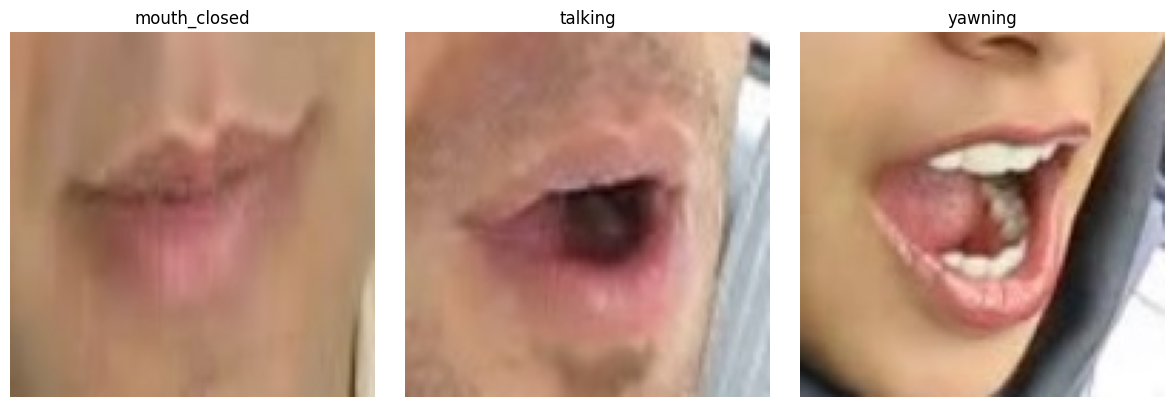

In [19]:
# ============================================================
# VISUALIZE RANDOM CROPS
# ============================================================

import random

sample_images = []

for class_name in CLASSES:

    folder = os.path.join(

        OUTPUT_DATASET,

        class_name

    )

    files = [

        f for f in os.listdir(folder)

        if f.lower().endswith(VALID_EXTENSIONS)

    ]

    if len(files):

        sample_images.append(

            (

                class_name,

                os.path.join(

                    folder,

                    random.choice(files)

                )

            )

        )

plt.figure(figsize=(12,4))

for i, (label, img_path) in enumerate(sample_images):

    img = cv2.imread(img_path)

    img = cv2.cvtColor(

        img,

        cv2.COLOR_BGR2RGB

    )

    plt.subplot(

        1,

        len(sample_images),

        i + 1

    )

    plt.imshow(img)

    plt.title(label)

    plt.axis("off")

plt.tight_layout()

plt.show()